Neste notebook estarei implementando uma rede neural para ... no dataset Indoor Scene recognition, que contém 67 classes com 15600 imagens no total, a partir de transfer learning da rede ...

Baixano o dataset:

In [2]:
!wget http://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar -P ..

--2026-03-08 14:27:00--  http://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar
Resolving groups.csail.mit.edu (groups.csail.mit.edu)... 128.52.131.233
Connecting to groups.csail.mit.edu (groups.csail.mit.edu)|128.52.131.233|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar [following]
--2026-03-08 14:27:00--  https://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar
Connecting to groups.csail.mit.edu (groups.csail.mit.edu)|128.52.131.233|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2592010240 (2.4G) [application/x-tar]
Saving to: ‘../indoorCVPR_09.tar’

indoorCVPR_09.tar   100%[===================>]   2.41G  8.70MB/s    in 4m 51s  

2026-03-08 14:31:51 (8.51 MB/s) - ‘../indoorCVPR_09.tar’ saved [2592010240/2592010240]



Descompactando o Dataset:

In [5]:
!tar -xvf ../indoorCVPR_09.tar -C ..

Images/
Images/airport_inside/
Images/airport_inside/airport_inside_0001.jpg
Images/airport_inside/airport_inside_0002.jpg
Images/airport_inside/airport_inside_0003.jpg
Images/airport_inside/airport_inside_0004.jpg
Images/airport_inside/airport_inside_0005.jpg
Images/airport_inside/airport_inside_0006.jpg
Images/airport_inside/airport_inside_0048.jpg
Images/airport_inside/airport_inside_0007.jpg
Images/airport_inside/airport_inside_0008.jpg
Images/airport_inside/airport_inside_0009.jpg
Images/airport_inside/airport_inside_0010.jpg
Images/airport_inside/airport_inside_0011.jpg
Images/airport_inside/airport_inside_0012.jpg
Images/airport_inside/airport_inside_0013.jpg
Images/airport_inside/airport_inside_0047.jpg
Images/airport_inside/airport_inside_0014.jpg
Images/airport_inside/airport_inside_0015.jpg
Images/airport_inside/airport_inside_0049.jpg
Images/airport_inside/airport_inside_0016.jpg
Images/airport_inside/airport_inside_0017.jpg
Images/airport_inside/airport_inside_0018.jpg
Ima

Definição do Dataset:

In [1]:
print("oi")

oi


In [40]:
import os

numFilePerFolder = [len(files) for root, dirs, files in os.walk('../Images') if len(files) > 0]
folders = [dirs for root, dirs, files in os.walk('../Images') if len(dirs) > 0][0]

folders, numFilePerFolder

(['videostore',
  'elevator',
  'buffet',
  'dining_room',
  'hairsalon',
  'classroom',
  'mall',
  'clothingstore',
  'airport_inside',
  'locker_room',
  'children_room',
  'dentaloffice',
  'florist',
  'hospitalroom',
  'fastfood_restaurant',
  'library',
  'closet',
  'inside_subway',
  'toystore',
  'inside_bus',
  'kindergarden',
  'nursery',
  'bowling',
  'warehouse',
  'museum',
  'waitingroom',
  'computerroom',
  'laboratorywet',
  'pantry',
  'cloister',
  'bakery',
  'restaurant',
  'grocerystore',
  'trainstation',
  'bedroom',
  'stairscase',
  'meeting_room',
  'church_inside',
  'greenhouse',
  'shoeshop',
  'jewelleryshop',
  'winecellar',
  'garage',
  'livingroom',
  'prisoncell',
  'artstudio',
  'poolinside',
  'deli',
  'gameroom',
  'concert_hall',
  'restaurant_kitchen',
  'bathroom',
  'lobby',
  'subway',
  'tv_studio',
  'kitchen',
  'gym',
  'studiomusic',
  'bar',
  'casino',
  'bookstore',
  'office',
  'auditorium',
  'corridor',
  'operating_room',
  

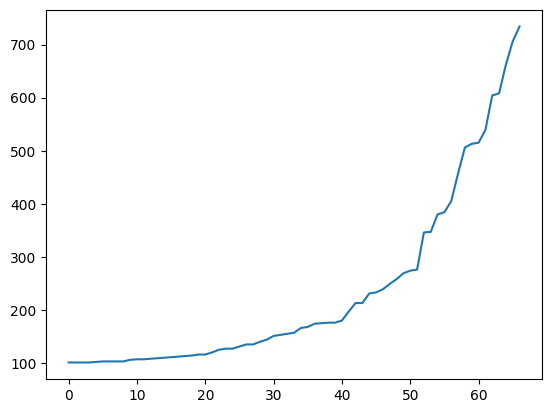

In [10]:
import matplotlib.pyplot as plt
plt.plot(sorted(numFilePerFolder))

Filtra apenas quais pastas (classes) contém mais do que 600 imagens para que o treinamento seja mais rápido e com maior qualidade, já que isso também evita overfitting:

In [17]:
import numpy as np

np.array(numFilePerFolder)

array([110, 101, 111, 274, 239, 113, 176, 106, 608, 249, 112, 131, 103,
       101, 116, 107, 135, 457, 347, 102, 127, 144, 213, 506, 168, 151,
       114, 125, 384, 120, 405, 513, 213, 153, 662, 155, 233, 180, 101,
       116, 157, 269, 103, 706, 103, 140, 174, 258, 127, 103, 107, 197,
       101, 539, 166, 734, 231, 108, 604, 515, 380, 109, 176, 346, 135,
       276, 175])

In [22]:
mask = np.array(numFilePerFolder) > 600
mask

array([False, False, False, False, False, False, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False,  True, False, False, False, False,
       False, False, False, False])

In [ ]:
# Transforma False em 0 e True em 1, e soma tudo
sum(mask)

np.int64(5)

In [38]:
# Precisa transformar em np.array para aplicar indexação booleana com mask
foldersToKeep = ((np.array(folders))[mask]).tolist()

foldersToKeep

['airport_inside', 'bedroom', 'livingroom', 'kitchen', 'bar']

Apaga de Images as pastas que não estão em foldersToKeep:

In [42]:
import shutil

[shutil.rmtree('../Images/' + folder) for folder in folders if folder not in foldersToKeep]

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

Atualiza as váriaveis numFilesPerFolder e folders, e cria fileNames, uma lista de listas fileNames com listas com os nomes de todas as imagens que sobraram no Dataset para cada diretório:

In [46]:
numFilePerFolder = [len(files) for root, dirs, files in os.walk('../Images') if len(files) > 0]
folders = [dirs for root, dirs, files in os.walk('../Images') if len(dirs) > 0][0]
fileNames = [os.listdir('../Images/' + folder) for folder in folders]

numFilePerFolder, folders, fileNames

([608, 662, 706, 734, 604],
 ['airport_inside', 'bedroom', 'livingroom', 'kitchen', 'bar'],
 [['airport_inside_0377.jpg',
   'airport_inside_0404.jpg',
   'airport_inside_0317.jpg',
   'airport_inside_0091.jpg',
   'airport_inside_0385.jpg',
   'airport_inside_0120.jpg',
   'airport_inside_0499.jpg',
   'airport_inside_0265.jpg',
   'airport_inside_0261.jpg',
   'airport_inside_0225.jpg',
   'airport_inside_0104.jpg',
   'airport_inside_0190.jpg',
   'airport_inside_0270.jpg',
   'airport_inside_0037.jpg',
   'airport_inside_0320.jpg',
   'airport_inside_0060.jpg',
   'airport_inside_0473.jpg',
   'airport_inside_0274.jpg',
   'airport_inside_0067.jpg',
   'airport_inside_0084.jpg',
   'airport_inside_0024.jpg',
   'airport_inside_0260.jpg',
   'airport_inside_0198.jpg',
   'airport_inside_0275.jpg',
   'airport_inside_0516.jpg',
   'airport_inside_0521.jpg',
   'airport_inside_0232.jpg',
   'airport_inside_0453.jpg',
   'airport_inside_0513.jpg',
   'airport_inside_0196.jpg',
   'airp

Separa o dataset entre treino e teste:

In [ ]:
np.random.seed(23)

# 20% das imagens em cada diretorio (Que estão agrupados em files), entrarão no dataset de teste.
filesToTest = [sorted(np.random.choice(files, round(numFiles * 0.2), replace = False)) for files, numFiles in zip(fileNames, numFilePerFolder)]
# Transforma cada entrada na lista de listsa filesToTest em string.
filesToTest = [[str(x) for x in sublista] for sublista in filesToTest]

filesToTest

[['airport_inside_0001.jpg',
  'airport_inside_0004.jpg',
  'airport_inside_0013.jpg',
  'airport_inside_0017.jpg',
  'airport_inside_0029.jpg',
  'airport_inside_0035.jpg',
  'airport_inside_0036.jpg',
  'airport_inside_0038.jpg',
  'airport_inside_0045.jpg',
  'airport_inside_0053.jpg',
  'airport_inside_0055.jpg',
  'airport_inside_0059.jpg',
  'airport_inside_0077.jpg',
  'airport_inside_0083.jpg',
  'airport_inside_0084.jpg',
  'airport_inside_0096.jpg',
  'airport_inside_0098.jpg',
  'airport_inside_0101.jpg',
  'airport_inside_0106.jpg',
  'airport_inside_0108.jpg',
  'airport_inside_0109.jpg',
  'airport_inside_0112.jpg',
  'airport_inside_0119.jpg',
  'airport_inside_0126.jpg',
  'airport_inside_0138.jpg',
  'airport_inside_0152.jpg',
  'airport_inside_0157.jpg',
  'airport_inside_0159.jpg',
  'airport_inside_0162.jpg',
  'airport_inside_0165.jpg',
  'airport_inside_0171.jpg',
  'airport_inside_0188.jpg',
  'airport_inside_0193.jpg',
  'airport_inside_0194.jpg',
  'airport_ins

Cria um diretorio test contendo apenas as imagens do dataset de teste dentro de Images. Para isso, cada imagem do dataset de teste é movida para esse novo diretório test:

In [52]:
# Cria um diretório test dentro de images.
os.makedirs('../Images/test/', exist_ok=True)
# Cria diretórios dentro de test para cada diretório em folders, que contém apenas os diretórios do dataset original que tem mais de 600 imagens.
[os.mkdir('../Images/test/' + folder) for folder in folders]
# Move da origem para o destino para cada file em cada diretorio escolhido.
[shutil.move('../Images/' + folder + '/' + file, '../Images/test/' + folder + '/' + file)
 for files, folder in zip(filesToTest, folders)
  for file in files]

['../Images/test/airport_inside/airport_inside_0001.jpg',
 '../Images/test/airport_inside/airport_inside_0004.jpg',
 '../Images/test/airport_inside/airport_inside_0013.jpg',
 '../Images/test/airport_inside/airport_inside_0017.jpg',
 '../Images/test/airport_inside/airport_inside_0029.jpg',
 '../Images/test/airport_inside/airport_inside_0035.jpg',
 '../Images/test/airport_inside/airport_inside_0036.jpg',
 '../Images/test/airport_inside/airport_inside_0038.jpg',
 '../Images/test/airport_inside/airport_inside_0045.jpg',
 '../Images/test/airport_inside/airport_inside_0053.jpg',
 '../Images/test/airport_inside/airport_inside_0055.jpg',
 '../Images/test/airport_inside/airport_inside_0059.jpg',
 '../Images/test/airport_inside/airport_inside_0077.jpg',
 '../Images/test/airport_inside/airport_inside_0083.jpg',
 '../Images/test/airport_inside/airport_inside_0084.jpg',
 '../Images/test/airport_inside/airport_inside_0096.jpg',
 '../Images/test/airport_inside/airport_inside_0098.jpg',
 '../Images/te

Cria um diretorio train contendo apenas as imagens do dataset de treino que sobraram:

In [ ]:
os.makedirs('../Images/train/', exist_ok=True)
# Aqui não precisa mover cada imagem, apenas os diretorios.
[shutil.move('../Images/' + folder, '../Images/train/' + folder) 
 for folder in folders
 if os.path.exists('../Images/' + folder)]


[]

Renomeia o diretorio Images para datasetIndoorSceneRecognition:

In [59]:
os.rename('../Images', '../datasetIndoorSceneRecognition')